<a href="https://colab.research.google.com/github/vinnybun/GPA-predictor-/blob/main/notebook%3F/colab/GPA_PREDICTOR_APP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
#Install dependencies
!pip install pandas matplotlib scikit-learn streamlit pyngrok

In [35]:
#upload CSV
from google.colab import files
uploaded = files.upload()

import pandas as pd
df_raw = pd.read_csv(list(uploaded.keys())[0])

df_raw.head()

Saving Grade data - Sheet1.csv to Grade data - Sheet1 (2).csv


,COURSE,UNIT,GRADE,SEMESTER
0,Engineering Drawing I,1,D,1
1,Elementary Mathematics I,4,A,1
2,General Phyisis I,4,B,1
3,Workshop Practice I,1,B,1
4,General Chemistry I,4,B,1


In [45]:
#data loader
import pandas as pd

GRADE_MAP = {"A":5,"B":4,"C":3,"D":2,"E":1,"F":0}

def map_semester(sem):
    try:
        sem = int(sem)
        year = (sem + 1) // 2
        semester_type = "Harmattan Semester" if sem % 2 == 1 else "Rain Semester"
        return f"Year {year} - {semester_type}"
    except:
        return None

def validate_and_clean(df):
    df.columns = [col.strip().lower() for col in df.columns]
    warnings = []
    clean_rows = []

    for idx, row in df.iterrows():
        course = str(row["course"]).strip()
        grade = str(row["grade"]).strip().upper()

        try:
            unit = float(row["unit"])
            if unit <= 0:
                raise ValueError
        except:
            warnings.append(f"Row {idx+1}: Invalid unit")
            continue

        if grade not in GRADE_MAP:
            warnings.append(f"Row {idx+1}: Invalid grade {grade}")
            continue

        semester_label = map_semester(row["semester"])
        if semester_label is None:
            warnings.append(f"Row {idx+1}: Invalid semester")
            continue

        clean_rows.append({
            "course": course,
            "unit": unit,
            "grade": grade,
            "grade_point": GRADE_MAP[grade],
            "semester": semester_label
        })

    return pd.DataFrame(clean_rows), warnings

clean_df, warnings = validate_and_clean(df_raw)

print("Warnings:", warnings)
clean_df.head()

Warnings: []


,course,unit,grade,grade_point,semester
0,Engineering Drawing I,1.0,D,2,Year 1 - Harmattan Semester
1,Elementary Mathematics I,4.0,A,5,Year 1 - Harmattan Semester
2,General Phyisis I,4.0,B,4,Year 1 - Harmattan Semester
3,Workshop Practice I,1.0,B,4,Year 1 - Harmattan Semester
4,General Chemistry I,4.0,B,4,Year 1 - Harmattan Semester


In [ ]:
l

In [46]:
#GPA calculator
import re

def extract_semester_order(semester_label):
    nums = list(map(int, re.findall(r'\d+', semester_label)))
    year = nums[0]
    sem = 1 if "Harmattan" in semester_label else 2
    return (year * 2) - (2 - sem)

def calculate_gpa(df):
    results = []
    grouped = df.groupby("semester")

    for semester, group in grouped:
        total_units = group["unit"].sum()
        total_points = (group["unit"] * group["grade_point"]).sum()
        gpa = total_points / total_units

        results.append({
            "semester": semester,
            "order": extract_semester_order(semester),
            "GPA": round(gpa,2)
        })

    df_out = pd.DataFrame(results)
    return df_out.sort_values("order")

def calculate_cgpa(df):
    total_units = df["unit"].sum()
    total_points = (df["unit"] * df["grade_point"]).sum()
    return round(total_points / total_units,2)

def calculate_cumulative_gpa(df):
    semesters = sorted(df["semester"].unique(), key=extract_semester_order)

    cum_units = 0
    cum_points = 0
    results = []

    for sem in semesters:
        sem_df = df[df["semester"] == sem]
        units = sem_df["unit"].sum()
        points = (sem_df["unit"] * sem_df["grade_point"]).sum()

        cum_units += units
        cum_points += points

        results.append({
            "semester": sem,
            "CGPA": round(cum_points / cum_units,2)
        })

    return pd.DataFrame(results)

semester_gpa = calculate_gpa(clean_df)
cgpa = calculate_cgpa(clean_df)
cumulative_df = calculate_cumulative_gpa(clean_df)

print(semester_gpa)
print("CGPA:", cgpa)
print(cumulative_df)

                      semester  order   GPA
0  Year 1 - Harmattan Semester      1  3.90
1       Year 1 - Rain Semester      2  3.60
2  Year 2 - Harmattan Semester      3  4.30
3       Year 2 - Rain Semester      4  4.45
4  Year 3 - Harmattan Semester      5  3.74
5       Year 3 - Rain Semester      6  4.05
6  Year 4 - Harmattan Semester      7  3.16
7       Year 4 - Rain Semester      8  5.00
8  Year 5 - Harmattan Semester      9  3.40
9       Year 5 - Rain Semester     10  4.14
CGPA: 3.91
                      semester  CGPA
0  Year 1 - Harmattan Semester  3.90
1       Year 1 - Rain Semester  3.76
2  Year 2 - Harmattan Semester  3.93
3       Year 2 - Rain Semester  4.06
4  Year 3 - Harmattan Semester  3.99
5       Year 3 - Rain Semester  4.00
6  Year 4 - Harmattan Semester  3.89
7       Year 4 - Rain Semester  3.93
8  Year 5 - Harmattan Semester  3.88
9       Year 5 - Rain Semester  3.91


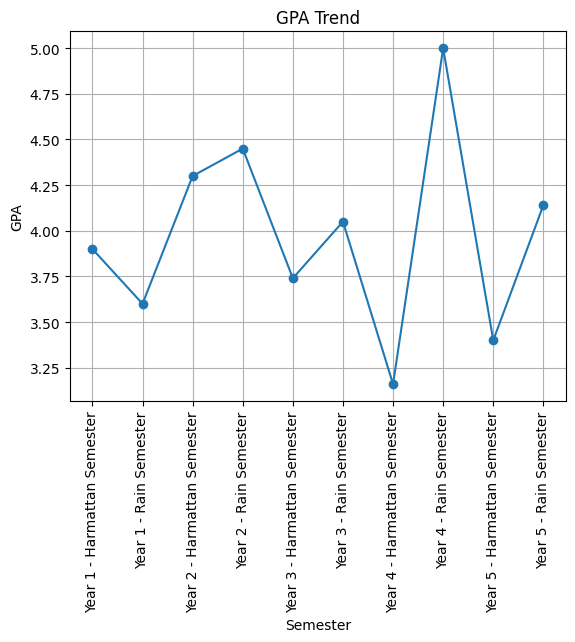

In [48]:
#Visualization
import matplotlib.pyplot as plt

def plot_gpa_trend(df):
    plt.figure()
    plt.plot(df["semester"], df["GPA"], marker='o')
    plt.xticks(rotation=90)
    plt.title("GPA Trend")
    plt.xlabel("Semester")
    plt.ylabel("GPA")
    plt.grid()
    plt.show()

plot_gpa_trend(semester_gpa)

In [49]:
#What IF scenerio
def compute_new_cgpa(current_df, courses):
    rows = []
    for c in courses:
        rows.append({
            "course": c["course"],
            "unit": c["unit"],
            "grade": c["grade"],
            "grade_point": GRADE_MAP[c["grade"]],
            "semester": "Hypothetical"
        })

    new_df = pd.concat([current_df, pd.DataFrame(rows)])
    total_units = new_df["unit"].sum()
    total_points = (new_df["unit"] * new_df["grade_point"]).sum()

    return round(total_points / total_units,2)

hypo = [{"course":"AI","unit":3,"grade":"A"}]

print("New CGPA:", compute_new_cgpa(clean_df, hypo))

New CGPA: 3.93


In [50]:
#ML Prediction
from sklearn.linear_model import LinearRegression
import numpy as np

def extract_semester_number(label):
    nums = list(map(int, re.findall(r'\d+', label)))
    year = nums[0]
    sem = 1 if "Harmattan" in label else 2
    return (year * 2) - (2 - sem)

cumulative_df["sem_num"] = cumulative_df["semester"].apply(extract_semester_number)

X = cumulative_df[["sem_num"]]
y = cumulative_df["CGPA"]

model = LinearRegression().fit(X,y)

next_sem = np.array([[X["sem_num"].max()+1]])
pred = model.predict(next_sem)[0]

print("Predicted CGPA:", round(pred,2))

Predicted CGPA: 3.94


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [80]:
#Create Streamlit APP
app_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np
import re

st.set_page_config(page_title="GPA AI Dashboard", layout="wide")

st.title("🎓 GPA AI Dashboard")
st.markdown("Analyze • Simulate • Predict • Plan your academic performance")

GRADE_MAP = {"A":5,"B":4,"C":3,"D":2,"E":1,"F":0}

# =========================
# HELPER FUNCTIONS
# =========================
def map_semester(sem):
    sem = int(sem)
    year = (sem + 1) // 2
    sem_type = "Harmattan" if sem % 2 == 1 else "Rain"
    return f"Year {year} - {sem_type} Semester"

def extract_sem_num(label):
    nums = list(map(int, re.findall(r'\\d+', label)))
    year = nums[0]
    sem = 1 if "Harmattan" in label else 2
    return (year * 2) - (2 - sem)

def calculate_gpa(df):
    return df.groupby("semester").apply(
        lambda x: (x["unit"] * x["grade_point"]).sum() / x["unit"].sum()
    ).reset_index(name="GPA")

def calculate_cgpa(df):
    total_units = df["unit"].sum()
    total_points = (df["unit"] * df["grade_point"]).sum()
    return round(total_points / total_units, 2)

# =========================
# SIDEBAR INPUT
# =========================
st.sidebar.header("⚙️ Input Settings")

mode = st.sidebar.radio("Input Method", ["Upload CSV", "Manual Entry"])

data = pd.DataFrame()

# =========================
# CSV INPUT
# =========================
if mode == "Upload CSV":
    uploaded = st.sidebar.file_uploader("Upload CSV", type=["csv"])
    if uploaded:
        df = pd.read_csv(uploaded)
        df["grade"] = df["grade"].str.upper()
        df["grade_point"] = df["grade"].map(GRADE_MAP)
        df["semester"] = df["semester"].apply(map_semester)
        data = df
        st.success("CSV Loaded Successfully")

# =========================
# MANUAL INPUT
# =========================
else:
    st.sidebar.subheader("✍️ Manual Entry")
    num_courses = st.sidebar.number_input("Number of Courses", 1, 15, 3)

    rows = []
    for i in range(num_courses):
        course = st.sidebar.text_input(f"Course {i+1}", key=f"c{i}")
        unit = st.sidebar.number_input(f"Unit {i+1}", 1, 6, key=f"u{i}")
        grade = st.sidebar.selectbox(f"Grade {i+1}", ["A","B","C","D","E","F"], key=f"g{i}")

        year = st.sidebar.number_input(f"Year {i+1}", 1, 10, key=f"y{i}")
        sem_type = st.sidebar.selectbox(f"Semester Type {i+1}", ["Harmattan","Rain"], key=f"st{i}")

        semester = f"Year {year} - {sem_type} Semester"

        rows.append({
            "course": course,
            "unit": unit,
            "grade": grade,
            "grade_point": GRADE_MAP[grade],
            "semester": semester
        })

    data = pd.DataFrame(rows)

# =========================
# MAIN APP
# =========================
if not data.empty:

    gpa_df = calculate_gpa(data)
    cgpa = calculate_cgpa(data)

    gpa_df["sem_num"] = gpa_df["semester"].apply(extract_sem_num)
    gpa_df = gpa_df.sort_values("sem_num")

    tab1, tab2, tab3, tab4, tab5 = st.tabs([
        "📊 Dashboard",
        "📉 Trends",
        "🧪 What-if",
        "🤖 Prediction",
        "🎯 Target CGPA"
    ])

    # =========================
    # DASHBOARD
    # =========================
    with tab1:
        col1, col2 = st.columns(2)
        col1.metric("🎯 Current CGPA", cgpa)
        col2.metric("📚 Total Courses", len(data))

        st.dataframe(data)

        # Performance insight
        if len(gpa_df) > 1:
            if gpa_df["GPA"].iloc[-1] > gpa_df["GPA"].iloc[-2]:
                st.success("📈 Your performance is improving")
            else:
                st.warning("📉 Your performance is declining")

    # =========================
    # TRENDS
    # =========================
    with tab2:
        plt.figure()
        plt.plot(gpa_df["semester"], gpa_df["GPA"], marker='o')
        plt.xticks(rotation=45)
        plt.title("GPA Trend")
        plt.grid()
        st.pyplot(plt)

    # =========================
    # WHAT-IF
    # =========================
    with tab3:
        num = st.number_input("Future courses", 1, 10, 2)

        hypo = []
        for i in range(num):
            col1, col2, col3 = st.columns(3)
            with col1:
                course = st.text_input(f"Course {i}", key=f"h{i}")
            with col2:
                unit = st.number_input(f"Unit {i}", 1, 6, key=f"hu{i}")
            with col3:
                grade = st.selectbox(f"Grade {i}", ["A","B","C","D","E","F"], key=f"hg{i}")

            hypo.append({
                "course": course,
                "unit": unit,
                "grade": grade,
                "grade_point": GRADE_MAP[grade]
            })

        if st.button("Run Scenario"):
            new_df = pd.concat([data, pd.DataFrame(hypo)])
            new_cgpa = calculate_cgpa(new_df)

            st.metric("New CGPA", new_cgpa)

    # =========================
    # AI PREDICTION
    # =========================
    with tab4:
        X = gpa_df[["sem_num"]]
        y = gpa_df["GPA"]

        model = LinearRegression().fit(X,y)
        pred = model.predict([[X["sem_num"].max()+1]])[0]

        st.metric("Predicted Next GPA", round(pred,2))

    # =========================
    # TARGET CGPA
    # =========================
    with tab5:
        target = st.number_input("Target CGPA", 0.0, 5.0, step=0.1)

        total_units = data["unit"].sum()
        total_points = (data["unit"] * data["grade_point"]).sum()

        future_units = st.number_input("Next semester total units", 1, 30, 15)

        required_points = target * (total_units + future_units) - total_points
        required_gpa = required_points / future_units

        st.metric("Required GPA Next Semester", round(required_gpa,2))

        if required_gpa > 5:
            st.error("⚠️ Target not achievable")
        else:
            st.success("🎯 You can achieve this!")

    # =========================
    # DOWNLOAD REPORT
    # =========================
    report = data.to_csv(index=False).encode("utf-8")
    st.download_button("📄 Download Report", report, "gpa_report.csv")

else:
    st.info("👈 Upload or input data to begin")

"""
with open("app.py","w") as f:
    f.write(app_code)

In [81]:
#Ngrok Setup
from pyngrok import ngrok
import streamlit as st

ngrok.set_auth_token("3C2xsoJr2AlNPND8KySCAw46Ju6_7Yi6PPHTqeuvkewCXErU1")

In [93]:
#Run Streamlit
get_ipython().system_raw("streamlit run app.py --server.port 8501 &")


public_url = ngrok.connect(8501)
print("🚀 LIVE LINK:", public_url)


PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 5 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3C2ylEHoF5kjf2FQWz6UTwApPmp, tn_3C2zTbUHboT0SLOpDqum0hlGb8m, tn_3C30UQmp3XtfWN98AzxqOUFtZJg, tn_3C30gR2toGEJ8KLVgtGTzd09Cpy, tn_3C30qOFG8l2kkIpPHQLQxuqhHUN.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}


In [86]:
#create the project structure
import os

os.makedirs("gpa-ai-dashboard/data", exist_ok=True)
os.makedirs("gpa-ai-dashboard/notebooks", exist_ok=True)

print(" Folder structure created")

 Folder structure created


In [87]:
#save the final copy
with open("gpa-ai-dashboard/app.py", "w") as f:
    f.write(app_code)

print(" app.py saved")

 app.py saved


In [88]:
#requirement.txt file
requirements = """streamlit
pandas
matplotlib
scikit-learn
numpy
"""

with open("gpa-ai-dashboard/requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt saved")

requirements.txt saved


In [89]:
#sample result file
sample_csv = """course,unit,grade,semester
Mathematics I,3,A,1
Physics I,3,B,1
Chemistry I,3,C,1
Mathematics II,3,A,2
Physics II,3,B,2
"""

with open("gpa-ai-dashboard/data/sample_results.csv", "w") as f:
    f.write(sample_csv)

print("sample_results.csv saved")

sample_results.csv saved


In [96]:
#readme file
readme = """# GPA AI Dashboard

A data-driven GPA analytics and prediction system built with Python and Streamlit.

---

##  Features

- GPA & CGPA calculation
- Trend visualization
- What-if simulation
- AI prediction (Linear Regression)
- Target CGPA planner
- Performance insights
- CSV report download

---

##  Tech Stack

- Python
- pandas
- matplotlib
- scikit-learn
- Streamlit

---

## ▶ Run the App

pip install -r requirements.txt
streamlit run app.py

---

##  Structure

gpa-ai-dashboard/
│
├── app.py
├── requirements.txt
├── README.md
│
├── data/
│   └── sample_results.csv

---

##  Author

"Albert Uchechukwu Vincent

"""

with open("gpa-ai-dashboard/README.md", "w") as f:
    f.write(readme)

print(" README.md saved")

 README.md saved


In [97]:
#zip the project
import shutil

shutil.make_archive("gpa-ai-dashboard", 'zip', "gpa-ai-dashboard")

print("Project zipped")

Project zipped


In [98]:
#project download
from google.colab import files

files.download("gpa-ai-dashboard.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>